# Sampling Distribution
___


## Fórmulas

**Média:**     $E[\hat{p}] = p$

**Variância:** $\sigma^2_{\hat{p}} = \dfrac{p(1-p)}{n}$

**SE:**        $\sigma_{\hat{p}} = \sqrt{\dfrac{p(1-p)}{n}}$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

rng = np.random.default_rng(seed=42)

# SECTION 1 — SAMPLING DISTRIBUTION

**Teoria:**
A sampling distribution é a distribuição de uma estatística
($\bar{x}$, $\hat{p}$) calculada a partir de todas as amostras
possíveis de tamanho $n$. Ela responde:
*"Se eu repetisse minha coleta infinitas vezes, como $\bar{x}$ se distribuiria?"*

**Fórmulas:**
$$E[\bar{x}] = \mu \qquad SE = \frac{\sigma}{\sqrt{n}}$$
```python
mu    = 100
sigma = 20
n     = 25

# a) Média esperada da sampling distribution
E_x_bar = mu
print(f"a) E[x̄] = μ = {E_x_bar}")

# b) Standard Error
SE = sigma / np.sqrt(n)
print(f"b) SE = σ/√n = {sigma}/√{n} = {SE:.2f}")

# c) Intuição — por que SE diminui com n?
print("""
c) Intuição:
   Com n maior, valores extremos se cancelam ao calcular a média.
   A média de 100 pessoas é mais estável que a média de 2 pessoas.
   Matematicamente: SE = σ/√n → quadruplicar n reduz SE à metade.
""")
```

In [2]:
mu = 100
sigma = 20
n = 25

E_x_bar = mu
print(f"E[x̄] = μ = {E_x_bar}")

SE = sigma / np.sqrt(n)
print(f"SE = σ/√n = {sigma}/√{n} = {SE:.2f}")


E[x̄] = μ = 100
SE = σ/√n = 20/√25 = 4.00


## Q2: Simulação da Sampling Distribution

**Teoria:**
Construímos empiricamente a sampling distribution gerando
1000 amostras de tamanho 25 e calculando a média de cada uma.
O SE teórico ($\sigma/\sqrt{n}$) deve bater com o std simulado.

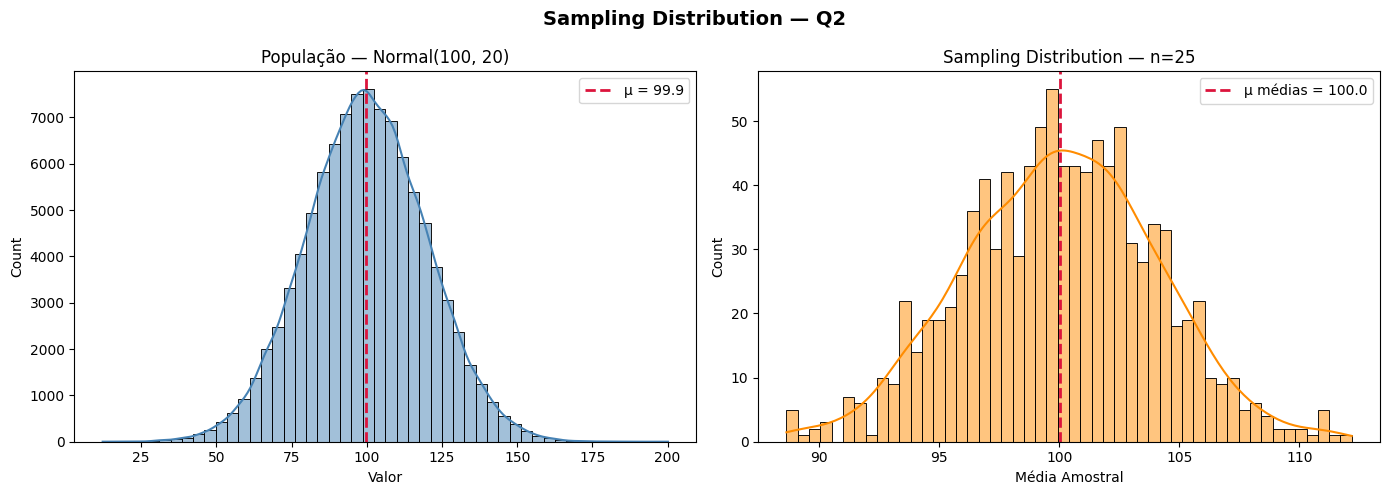

In [3]:
# Population
population = rng.normal(loc=100, scale=20, size=100_000)

# 1000 amostras de tamanho 25
samples = rng.choice(population, size=(1_000, 25), replace=True)
sample_means = samples.mean(axis=1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(population, bins=50, kde=True,
             color='steelblue', ax=axes[0])
axes[0].axvline(population.mean(), color='crimson',
                linestyle='--', linewidth=2,
                label=f'μ = {population.mean():.1f}')
axes[0].set_title('População — Normal(100, 20)', fontsize=12)
axes[0].set_xlabel('Valor')
axes[0].legend()

sns.histplot(sample_means, bins=50, kde=True,
             color='darkorange', ax=axes[1])
axes[1].axvline(sample_means.mean(), color='crimson',
                linestyle='--', linewidth=2,
                label=f'μ médias = {sample_means.mean():.1f}')
axes[1].set_title('Sampling Distribution — n=25', fontsize=12)
axes[1].set_xlabel('Média Amostral')
axes[1].legend()

plt.suptitle('Sampling Distribution — Q2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# b) Comparação empírico vs teórico
SE_teorico  = 20 / np.sqrt(25)
SE_empirico = sample_means.std()

print(f"SE teórico  (σ/√n):  {SE_teorico:.4f}")
print(f"SE empírico (simulado): {SE_empirico:.4f}")

SE teórico  (σ/√n):  4.0000
SE empírico (simulado): 4.0071


# SECTION 2 — CENTRAL LIMIT THEOREM
___

Por conta do CLT podemos deduzir que o valor esperado da amostra é a média populacional.

**"Se repertimos infinitas vezes a amostragem, a média amostral converge para a média populacional"**

Numa única amostra, $\bar{x} \neq \mu$ quase sempre. Mas em média, ao longo de muitas amostras, $\bar{x}$ converge para $\mu$.

**O CLT garante que a soma (ou média) de variáveis aleatórias
independentes converge para uma normal, independente da
distribuição original.**

In [5]:
print("""
a) Por que a sampling distribution se torna normal?

   Cada amostra é uma soma de n variáveis independentes.
   Pelo CLT, somas de variáveis independentes convergem
   para uma normal conforme n cresce — independente da
   distribuição original da população.

   Intuição: valores extremos de diferentes direções
   se cancelam. Com n grande, esses cancelamentos
   seguem um padrão gaussiano.
""")


a) Por que a sampling distribution se torna normal?

   Cada amostra é uma soma de n variáveis independentes.
   Pelo CLT, somas de variáveis independentes convergem
   para uma normal conforme n cresce — independente da
   distribuição original da população.

   Intuição: valores extremos de diferentes direções
   se cancelam. Com n grande, esses cancelamentos
   seguem um padrão gaussiano.



In [6]:
print("""
Quando o CLT falha ou é não-confiável?

   1. n pequeno (n < 30) com distribuições muito assimétricas
   2. Variáveis NÃO independentes (ex: séries temporais)
   3. Distribuições sem variância finita (ex: Cauchy)
   4. Amostras com outliers extremos que dominam a média
   5. Dados com estrutura de cluster (viola independência)
""")


Quando o CLT falha ou é não-confiável?

   1. n pequeno (n < 30) com distribuições muito assimétricas
   2. Variáveis NÃO independentes (ex: séries temporais)
   3. Distribuições sem variância finita (ex: Cauchy)
   4. Amostras com outliers extremos que dominam a média
   5. Dados com estrutura de cluster (viola independência)



## Q4: Confidence Interval

**Teoria:**
IC é o intervalo construído a partir da amostra que,
se repetido infinitas vezes, conteria o parâmetro real
em $(1-\alpha)$% dos casos.

$$CI_{95\%} = \bar{x} \pm z^* \cdot \frac{s}{\sqrt{n}}$$

Com $z^* = 1.96$ para 95% de confiança

In [7]:
x_bar = 52
s     = 10
n     = 100
z     = 1.96

SE = s / np.sqrt(n)
margin = z * SE

lower = x_bar - margin
upper = x_bar + margin

print(f"a) IC 95% = {x_bar} ± {z} × {SE:.2f}")
print(f"   IC 95% = [{lower:.2f}, {upper:.2f}]")

a) IC 95% = 52 ± 1.96 × 1.00
   IC 95% = [50.04, 53.96]


In [8]:
print("""
b) Interpretação frequentista CORRETA:
   "Se repetíssemos esse processo de amostragem 100 vezes,
    aproximadamente 95 dos intervalos construídos
    conteriam o verdadeiro valor de μ."

   NÃO é: "há 95% de chance de μ estar nesse intervalo."
   μ é fixo — ele está ou não está no intervalo.
   A aleatoriedade está no processo de construção do IC.
""")


b) Interpretação frequentista CORRETA:
   "Se repetíssemos esse processo de amostragem 100 vezes,
    aproximadamente 95 dos intervalos construídos
    conteriam o verdadeiro valor de μ."

   NÃO é: "há 95% de chance de μ estar nesse intervalo."
   μ é fixo — ele está ou não está no intervalo.
   A aleatoriedade está no processo de construção do IC.



## Q5: Interpretação Correta do IC

**Teoria:**
Na estatística frequentista, o parâmetro $\mu$ é fixo —
não tem distribuição de probabilidade.
A incerteza está na amostra, não no parâmetro.

In [9]:
print("""
Por que "95% de chance de μ estar no intervalo" está errado?

   μ é um valor FIXO da população — ele não varia.
   Ele está ou não está no intervalo. Probabilidade 0 ou 1.

   O que varia é o INTERVALO — construído a partir
   de cada amostra diferente.

   Analogia:
   Imagine atirar 100 laços em um poste fixo.
   O poste (μ) não se move.
   95 laços capturam o poste, 5 erram.
   Não faz sentido dizer "95% de chance do poste
   estar dentro do laço" — o poste é fixo.
   Os laços é que variam.
""")


Por que "95% de chance de μ estar no intervalo" está errado?

   μ é um valor FIXO da população — ele não varia.
   Ele está ou não está no intervalo. Probabilidade 0 ou 1.

   O que varia é o INTERVALO — construído a partir
   de cada amostra diferente.

   Analogia:
   Imagine atirar 100 laços em um poste fixo.
   O poste (μ) não se move.
   95 laços capturam o poste, 5 erram.
   Não faz sentido dizer "95% de chance do poste
   estar dentro do laço" — o poste é fixo.
   Os laços é que variam.



---

# SECTION 4 — HYPOTHESIS TESTING

---

**Teoria:**
O z-statistic mede quantos SEs a média amostral está
afastada da média hipotética sob $H_0$.

$$z = \frac{\bar{x} - \mu_0}{SE} = \frac{\bar{x} - \mu_0}{\sigma/\sqrt{n}}$$

In [10]:
x_bar  = 52
mu_0   = 50
s      = 10
n      = 100
alpha  = 0.05

SE = s / np.sqrt(n)

z_stat = (x_bar - mu_0) / SE
print(f"a) Z = ({x_bar} - {mu_0}) / {SE:.2f} = {z_stat:.4f}")

# b) p-value (two-tailed)
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
print(f"b) p-value (two-tailed) = {p_value:.4f}")

# c) Decisão
print(f"\nc) alpha = {alpha}")
if p_value < alpha:
    print(f"   p={p_value:.4f} < α={alpha} → Rejeita H₀")
    print("   Evidência de que μ ≠ 50")
else:
    print(f"   p={p_value:.4f} ≥ α={alpha} → Não rejeita H₀")

a) Z = (52 - 50) / 1.00 = 2.0000
b) p-value (two-tailed) = 0.0455

c) alpha = 0.05
   p=0.0455 < α=0.05 → Rejeita H₀
   Evidência de que μ ≠ 50


## Q7: Type I e Type II Errors

In [11]:
print("""
a) Definição:

   Erro Tipo I (α — falso positivo):
   Rejeitar H₀ quando ela é verdadeira.
   Ex: concluir que a feature melhorou conversão
       quando na verdade não mudou nada.

   Erro Tipo II (β — falso negativo):
   Não rejeitar H₀ quando ela é falsa.
   Ex: descartar uma feature que realmente funcionaria.

b) Qual é mais perigoso em A/B testing?

   Depende do custo de cada erro:

   Erro Tipo I → você lança uma feature que não funciona
   Custo: esforço de engenharia desperdiçado,
          possível degradação de UX

   Erro Tipo II → você mata uma feature que funcionaria
   Custo: oportunidade de crescimento perdida

   Na maioria dos produtos:
   Erro Tipo I é mais controlado (você define α=0.05).
   Erro Tipo II é frequentemente subestimado —
   amostras pequenas aumentam β silenciosamente.

   Regra prática sênior:
   Sempre calcule o poder do teste (1-β) antes de rodar.
   Poder < 0.80 significa risco alto de Erro Tipo II.
""")


a) Definição:

   Erro Tipo I (α — falso positivo):
   Rejeitar H₀ quando ela é verdadeira.
   Ex: concluir que a feature melhorou conversão
       quando na verdade não mudou nada.

   Erro Tipo II (β — falso negativo):
   Não rejeitar H₀ quando ela é falsa.
   Ex: descartar uma feature que realmente funcionaria.

b) Qual é mais perigoso em A/B testing?

   Depende do custo de cada erro:

   Erro Tipo I → você lança uma feature que não funciona
   Custo: esforço de engenharia desperdiçado,
          possível degradação de UX

   Erro Tipo II → você mata uma feature que funcionaria
   Custo: oportunidade de crescimento perdida

   Na maioria dos produtos:
   Erro Tipo I é mais controlado (você define α=0.05).
   Erro Tipo II é frequentemente subestimado —
   amostras pequenas aumentam β silenciosamente.

   Regra prática sênior:
   Sempre calcule o poder do teste (1-β) antes de rodar.
   Poder < 0.80 significa risco alto de Erro Tipo II.



---

# SECTION 5 — A/B TEST FUNDAMENTALS

---

## Q8: Conversion Rate

**Teoria:**
Taxa de conversão é a proporção $\hat{p} = \text{conversões}/n$.
Lift é a variação relativa entre tratamento e controle.

$$\text{lift} = \frac{\hat{p}_{treatment} - \hat{p}_{control}}{\hat{p}_{control}}$$

In [12]:
conv_control   = 200
n_control      = 2000
conv_treatment = 260
n_treatment    = 2000

# a) Conversion rates
p_control   = conv_control   / n_control
p_treatment = conv_treatment / n_treatment

print(f"a) Conversion rate controle:   {p_control:.4f} ({p_control*100:.1f}%)")
print(f"   Conversion rate tratamento: {p_treatment:.4f} ({p_treatment*100:.1f}%)")

# b) Lift
lift = (p_treatment - p_control) / p_control
print(f"\nb) Lift = ({p_treatment:.4f} - {p_control:.4f}) / {p_control:.4f}")
print(f"   Lift = {lift:.4f} ({lift*100:.1f}%)")

a) Conversion rate controle:   0.1000 (10.0%)
   Conversion rate tratamento: 0.1300 (13.0%)

b) Lift = (0.1300 - 0.1000) / 0.1000
   Lift = 0.3000 (30.0%)


## Q9: Two-Proportion Z-Test

**Teoria:**
Compara duas proporções usando proporção pooled
(estimativa combinada sob $H_0: p_1 = p_2$).

$$\hat{p}_{pool} = \frac{x_1 + x_2}{n_1 + n_2}$$

$$SE = \sqrt{\hat{p}_{pool}(1-\hat{p}_{pool})\left(\frac{1}{n_1} + \frac{1}{n_2}\right)}$$

$$z = \frac{\hat{p}_1 - \hat{p}_2}{SE}$$

In [13]:
# a) Pooled probability
p_pool = (conv_control + conv_treatment) / (n_control + n_treatment)
print(f"a) p_pool = {p_pool:.4f}")

# b) Standard error
SE = np.sqrt(p_pool * (1 - p_pool) * (1/n_control + 1/n_treatment))
print(f"b) SE = {SE:.4f}")

# c) Z-statistic
z_stat = (p_treatment - p_control) / SE
print(f"c) Z = {z_stat:.4f}")

# p-value e interpretação
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
print(f"\nd) p-value = {p_value:.4f}")

if p_value < 0.05:
    print("   Rejeita H₀ — diferença estatisticamente significativa")
    print(f"   Tratamento com {lift*100:.1f}% de lift sobre controle")
else:
    print("   Não rejeita H₀ — diferença pode ser ruído amostral")

a) p_pool = 0.1150
b) SE = 0.0101
c) Z = 2.9737

d) p-value = 0.0029
   Rejeita H₀ — diferença estatisticamente significativa
   Tratamento com 30.0% de lift sobre controle


---

# SECTION 6 — STATISTICAL POWER

---

In [14]:
print("""
a) Poder estatístico = 1 - β

   É a probabilidade de detectar um efeito real
   quando ele de fato existe.
   Convencionalmente: poder ≥ 0.80 (80%)

b) O que aumenta o poder?

   ↑ n          → SE menor → mais fácil detectar efeito
   ↑ effect size → efeito maior → mais fácil detectar
   ↑ α          → região de rejeição maior (trade-off com Tipo I)
   ↓ variância  → dados mais consistentes

c) O que acontece com n pequeno?

   SE grande → distribuições sob H₀ e H₁ se sobrepõem muito
   → difícil distinguir sinal de ruído
   → β alto → poder baixo
   → você pode ter um efeito real e não detectar (Tipo II)

   Consequência prática:
   Você desliga um teste A/B prematuramente e conclui
   que a feature não funciona — quando na verdade
   você só não tinha dados suficientes para ver o efeito.
""")


a) Poder estatístico = 1 - β

   É a probabilidade de detectar um efeito real
   quando ele de fato existe.
   Convencionalmente: poder ≥ 0.80 (80%)

b) O que aumenta o poder?

   ↑ n          → SE menor → mais fácil detectar efeito
   ↑ effect size → efeito maior → mais fácil detectar
   ↑ α          → região de rejeição maior (trade-off com Tipo I)
   ↓ variância  → dados mais consistentes

c) O que acontece com n pequeno?

   SE grande → distribuições sob H₀ e H₁ se sobrepõem muito
   → difícil distinguir sinal de ruído
   → β alto → poder baixo
   → você pode ter um efeito real e não detectar (Tipo II)

   Consequência prática:
   Você desliga um teste A/B prematuramente e conclui
   que a feature não funciona — quando na verdade
   você só não tinha dados suficientes para ver o efeito.



In [15]:
# Calculando n necessário para poder=0.80
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

effect = proportion_effectsize(p_treatment, p_control)
n_req  = NormalIndPower().solve_power(
    effect_size=effect,
    power=0.80,
    alpha=0.05,
    alternative='two-sided'
)
print(f"n necessário por grupo (poder=80%): {n_req:.0f}")

n necessário por grupo (poder=80%): 1768


---

# SECTION 7 — PRACTICAL PITFALLS

---

## Q11: Peeking Problem

In [16]:
print("""
Por que checar resultados diariamente é perigoso?

   Cada vez que você olha os dados e toma uma decisão,
   está efetivamente realizando um teste estatístico.

   Se você checa 20 vezes com α=0.05:
   P(pelo menos 1 falso positivo) = 1 - (0.95)^20 ≈ 64%

   Isso é a taxa de erro real — muito acima de 5%.

   O que acontece na prática:
   Você vê p=0.04 no dia 3 e para o teste.
   Mas se tivesse esperado, o p-value poderia ter voltado
   para 0.12 com mais dados.

   Solução:
   1. Definir n antes de começar (power analysis)
   2. Rodar até atingir n — sem olhar antes
   3. Usar Sequential Testing se precisar de early stopping
      (ex: método de O'Brien-Fleming)
""")


Por que checar resultados diariamente é perigoso?

   Cada vez que você olha os dados e toma uma decisão,
   está efetivamente realizando um teste estatístico.

   Se você checa 20 vezes com α=0.05:
   P(pelo menos 1 falso positivo) = 1 - (0.95)^20 ≈ 64%

   Isso é a taxa de erro real — muito acima de 5%.

   O que acontece na prática:
   Você vê p=0.04 no dia 3 e para o teste.
   Mas se tivesse esperado, o p-value poderia ter voltado
   para 0.12 com mais dados.

   Solução:
   1. Definir n antes de começar (power analysis)
   2. Rodar até atingir n — sem olhar antes
   3. Usar Sequential Testing se precisar de early stopping
      (ex: método de O'Brien-Fleming)



## Q12: Multiple Testing

In [17]:
print("""
O que acontece ao rodar 20 experimentos simultaneamente?

   Com α=0.05 por teste:
   P(pelo menos 1 falso positivo) = 1 - (0.95)^20 ≈ 64%

   Você esperaria ~1 falso positivo por puro acaso.

   Correções disponíveis:

   Bonferroni (conservadora):
   α_ajustado = α / m = 0.05 / 20 = 0.0025
   Controla fortemente Tipo I, mas aumenta Tipo II

   Benjamini-Hochberg — FDR (mais usada em DS):
   Controla a taxa de falsas descobertas (FDR)
   Menos conservadora que Bonferroni
   Melhor trade-off entre Tipo I e Tipo II
""")


O que acontece ao rodar 20 experimentos simultaneamente?

   Com α=0.05 por teste:
   P(pelo menos 1 falso positivo) = 1 - (0.95)^20 ≈ 64%

   Você esperaria ~1 falso positivo por puro acaso.

   Correções disponíveis:

   Bonferroni (conservadora):
   α_ajustado = α / m = 0.05 / 20 = 0.0025
   Controla fortemente Tipo I, mas aumenta Tipo II

   Benjamini-Hochberg — FDR (mais usada em DS):
   Controla a taxa de falsas descobertas (FDR)
   Menos conservadora que Bonferroni
   Melhor trade-off entre Tipo I e Tipo II



In [18]:
alpha  = 0.05
m      = 20
p_fp   = 1 - (1 - alpha)**m
alpha_bonferroni = alpha / m

print(f"P(≥1 falso positivo em {m} testes): {p_fp:.1%}")
print(f"α Bonferroni: {alpha_bonferroni:.4f}")

P(≥1 falso positivo em 20 testes): 64.2%
α Bonferroni: 0.0025


---

# SECTION 8 — BUSINESS INTERPRETATION

---

## Q13: Practical vs Statistical Significance

In [19]:
print("""
Conversão: 10% → 10.2%, p < 0.01

a) Vale a pena fazer o deploy?

   Não necessariamente — p < 0.01 só diz que a diferença
   provavelmente não é ruído. Não diz se é importante.

   Lift = (10.2 - 10.0) / 10.0 = 2%
   Diferença absoluta = 0.2 pontos percentuais

   Com n muito grande, até 0.001% de diferença
   pode ter p < 0.01 — mas não justifica deploy.

b) Informações adicionais necessárias:

   1. Receita por conversão — 0.2% de lift gera quanto em R$?
   2. Custo de implementação — engenharia, infraestrutura
   3. Impacto em métricas de guardrail — latência, bounce rate
   4. Tamanho do efeito (Cohen's h) — magnitude real
   5. Intervalo de confiança — [0.1%, 0.3%]?
      se o lower bound for desprezível, reconsidere
   6. Segmentação — o efeito é consistente entre grupos?
""")


Conversão: 10% → 10.2%, p < 0.01

a) Vale a pena fazer o deploy?

   Não necessariamente — p < 0.01 só diz que a diferença
   provavelmente não é ruído. Não diz se é importante.

   Lift = (10.2 - 10.0) / 10.0 = 2%
   Diferença absoluta = 0.2 pontos percentuais

   Com n muito grande, até 0.001% de diferença
   pode ter p < 0.01 — mas não justifica deploy.

b) Informações adicionais necessárias:

   1. Receita por conversão — 0.2% de lift gera quanto em R$?
   2. Custo de implementação — engenharia, infraestrutura
   3. Impacto em métricas de guardrail — latência, bounce rate
   4. Tamanho do efeito (Cohen's h) — magnitude real
   5. Intervalo de confiança — [0.1%, 0.3%]?
      se o lower bound for desprezível, reconsidere
   6. Segmentação — o efeito é consistente entre grupos?



## Q14: Threats to Experiment Validity

In [20]:
print("""
5+ ameaças à validade em A/B testing:

1. Selection Bias
   Grupos não são equivalentes antes do teste.
   Ex: usuários premium só no grupo tratamento.
   Solução: randomização correta + SRM check.

2. Novelty Effect
   Usuários interagem mais com qualquer coisa nova.
   O efeito some após a novidade passar.
   Solução: rodar o teste por tempo suficiente.

3. Network Effects (Spillover)
   Tratamento de um usuário afeta o comportamento de outro.
   Ex: social networks — viola independência das observações.
   Solução: cluster randomization.

4. Peeking / Early Stopping
   Encerrar o teste quando p < 0.05 aparece pela primeira vez.
   Infla taxa de falsos positivos drasticamente.
   Solução: definir n antes, respeitar o plano.

5. Multiple Testing
   Testar muitas métricas ou variantes sem correção.
   Aumenta P(falso positivo) cumulativamente.
   Solução: definir métrica primária antes, usar FDR.

6. Seasonality / External Events
   Feriados, campanhas, eventos externos durante o teste.
   Solução: rodar por ciclos completos (ex: semanas inteiras).

7. Sample Ratio Mismatch (SRM)
   Proporção real entre grupos ≠ proporção planejada.
   Indica bug no sistema de randomização.
   Solução: sempre verificar SRM antes de analisar resultados.
""")


5+ ameaças à validade em A/B testing:

1. Selection Bias
   Grupos não são equivalentes antes do teste.
   Ex: usuários premium só no grupo tratamento.
   Solução: randomização correta + SRM check.

2. Novelty Effect
   Usuários interagem mais com qualquer coisa nova.
   O efeito some após a novidade passar.
   Solução: rodar o teste por tempo suficiente.

3. Network Effects (Spillover)
   Tratamento de um usuário afeta o comportamento de outro.
   Ex: social networks — viola independência das observações.
   Solução: cluster randomization.

4. Peeking / Early Stopping
   Encerrar o teste quando p < 0.05 aparece pela primeira vez.
   Infla taxa de falsos positivos drasticamente.
   Solução: definir n antes, respeitar o plano.

5. Multiple Testing
   Testar muitas métricas ou variantes sem correção.
   Aumenta P(falso positivo) cumulativamente.
   Solução: definir métrica primária antes, usar FDR.

6. Seasonality / External Events
   Feriados, campanhas, eventos externos durante o test

# Resumo Final
```
Section 1-2: Sampling Distribution + CLT
→ Fundação teórica — E[x̄]=μ, SE=σ/√n, normalidade emergente

Section 3: Confidence Intervals
→ Ferramenta de quantificação de incerteza
→ Interpretação frequentista — o IC varia, μ é fixo

Section 4: Hypothesis Testing
→ Z-test, p-value, α, Tipo I vs Tipo II
→ Poder = 1-β — calcular ANTES de rodar

Section 5: A/B Test
→ Conversão, lift, two-proportion z-test
→ Pooled SE sob H₀

Section 6-7: Power + Pitfalls
→ n pequeno = poder baixo = Tipo II alto
→ Peeking e múltiplos testes inflam Tipo I

Section 8: Business
→ Significância estatística ≠ relevância prática
→ Sempre perguntar: qual o valor em R$ do efeito?
```

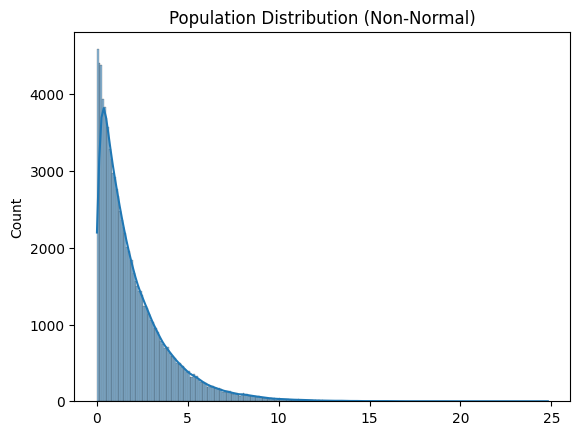

In [21]:
# população skewed (exponencial)
population = rng.exponential(scale=2, size=100000)

sns.histplot(population, kde=True)
plt.title("Population Distribution (Non-Normal)")
plt.show()

**Creating a sampling distribution from mean**

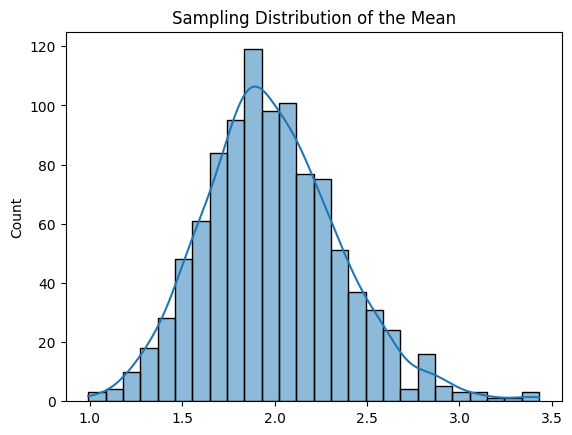

In [22]:
sample_size = 30
n_samples = 1000
sample_means = []

for _ in range(n_samples):
    sample = rng.choice(population, size=sample_size)
    sample_means.append(sample.mean())

sns.histplot(sample_means, kde=True)
plt.title("Sampling Distribution of the Mean")
plt.show()

Problema: Dada uma população uniforme:
```python
population = np.random.uniform(0, 10, 100000)
```
1. Gere 1000 amostras de tamanho 50
2. Calcule a média de cada amostra
3. Plote a sampling distribution
4. Compare média e desvio padrão com a população

In [23]:
population = rng.uniform(0, 10, 100_000)

In [24]:
# 1. Gere 1000 amostras de tamanho 50
# 2. Calcule a média de cada amostra
sample_size = 50
n_samples = 1000

sample_means = []

for _ in range(n_samples):
    sample = rng.choice(population, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))


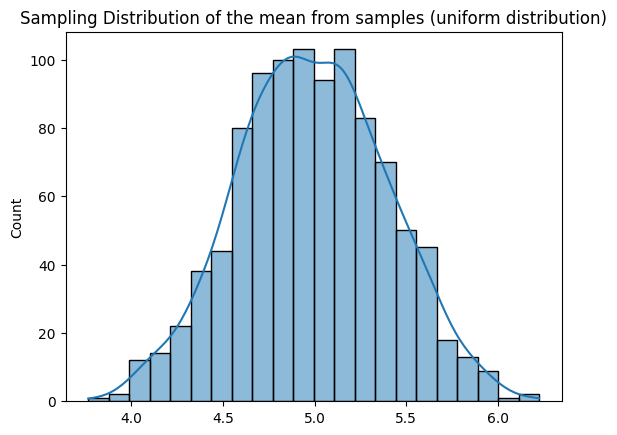

In [25]:
# 3. Plot a sampling distribution
sns.histplot(sample_means, kde=True)
plt.title("Sampling Distribution of the mean from samples (uniform distribution)")
plt.show()

In [26]:
# 4. Compare a média e o desvio padrão com a população
# uniforme distribuition -- population = rng.uniform(0, 10, 100_000)
# a = 0, b = 10, probabilidade uniforme em todo o intervalo size = 100000
a = 0
b = 10
mu = a + b / 2
sigma = (b-a)/(12)**0.5

print(f"Da população teórica uniforme temos mu={mu:.3f} e sigma={sigma:.3f} ")

Da população teórica uniforme temos mu=5.000 e sigma=2.887 


In [27]:
print("""Sample means é um vetor com 1000 valores, onde cada valor é o x_barra de um sample de tamanho 50
      
      Aonde temos o desvio padrão das médias""")
x_bar = np.mean(sample_means) #  ≈ μ = 5.0 (mu)
SE = np.std(sample_means)  # ≈ SE = σ/√n ≈ 0.408

print(f"A média amostral da distribuição é: {x_bar:.3f}")
print(f"O erro padrão  é {SE:.3f} -- o desvio padrão da distribuição amostral das médias")

Sample means é um vetor com 1000 valores, onde cada valor é o x_barra de um sample de tamanho 50

      Aonde temos o desvio padrão das médias
A média amostral da distribuição é: 4.989
O erro padrão  é 0.405 -- o desvio padrão da distribuição amostral das médias


```markdown
população (10.000 valores)
    → amostra 1 (50 valores) → calcula x̄₁, s₁
    → amostra 2 (50 valores) → calcula x̄₂, s₂
    → ...
    → amostra 1000 (50 valores) → calcula x̄₁₀₀₀, s₁₀₀₀

vetor sample_means = [x̄₁, x̄₂, ..., x̄₁₀₀₀]
    → np.mean(sample_means) ≈ μ
    → np.std(sample_means)  = SE empírico  ← não é s, é outra coisa
```

In [28]:
# Uma amostra qualquer — s descreve os dados
uma_amostra = rng.choice(population, size=50, replace=True)
s = np.std(uma_amostra, ddof=1)        # desvio padrão amostral

# O vetor de médias — std aqui é o SE
np.mean(sample_means)                  # ≈ μ (média das médias ≈ média da população)
np.std(sample_means)                   # ≈ SE empírico

# E o SE teórico, que você pode calcular sem simular nada
SE_teorico = np.std(population) / np.sqrt(50)   # σ/√n

print(SE_teorico)

0.40785929675226573


In [29]:
# s — desvio padrão de UMA amostra (50 dados brutos)
s = np.std(uma_amostra, ddof=1)

# SE empírico — desvio padrão DAS MÉDIAS (1000 médias)
SE = np.std(sample_means)

# Sampling Distribution — Onde vivem, o que comem, onde aplicar

---

## 1. O problema que justifica a existência delas

Na prática você tem **uma amostra**. Nunca a população inteira.

Você calcula a média da sua amostra (x̄) e quer responder:
*"Quão longe esse valor pode estar da média real da população (μ)?"*

Para responder isso, você precisa saber como x̄ se comporta — e é exatamente isso que a sampling distribution descreve.

---

## 2. Os três níveis (não confundir)

| Nível | O que é | Parâmetros | Existe onde |
|---|---|---|---|
| Distribuição teórica | O mecanismo gerador | μ, σ | Só na matemática |
| População simulada | Array grande que representa a população | x̄ ≈ μ, s ≈ σ | No código, para fins de estudo |
| Amostra | O que você tem na vida real | x̄, s calculados | No seu dataset |

```python
# Nível 1 — teórico: Uniforme(0, 10) → μ = 5.0, σ = 2.887
# Nível 2 — simulado:
population = rng.uniform(0, 10, 10_000)   # faz o papel da população
# Nível 3 — amostra real:
amostra = rng.choice(population, size=50)  # isso é o que você teria na prática
```

---

## 3. O que é a Sampling Distribution

É a distribuição de uma **estatística** (ex: x̄) calculada sobre muitas amostras do mesmo tamanho n retiradas da mesma população.

```python
sample_means = []
for _ in range(1000):
    amostra = rng.choice(population, size=50, replace=True)
    sample_means.append(np.mean(amostra))
# sample_means é a sampling distribution de x̄
```

**Ela não existe na prática** — você nunca coleta 1000 amostras do mesmo fenômeno. Você a *constrói* via simulação (como acima) ou via teoria (CLT).

---

## 4. A notação e o que cada símbolo descreve

| Símbolo | Nome | Onde vive | Calculado como |
|---|---|---|---|
| μ | Média da população | Nível teórico | (a+b)/2 para Uniforme |
| σ | Desvio padrão da população | Nível teórico | (b−a)/√12 para Uniforme |
| x̄ | Média amostral | Na sua amostra | np.mean(amostra) |
| s | Desvio padrão amostral | Na sua amostra | np.std(amostra, ddof=1) |
| SE | Standard Error | Na sampling distribution | σ/√n (teórico) ou s/√n (estimado) |

**Regra de ouro:** σ e μ descrevem os dados individuais. SE descreve a variabilidade das médias.

```python
# s — desvio padrão de UMA amostra (variabilidade dos dados brutos)
s = np.std(uma_amostra, ddof=1)

# SE empírico — std do vetor de médias (variabilidade das médias entre amostras)
SE_empirico = np.std(sample_means)

# SE teórico — calculado sem simular nada
SE_teorico = np.std(population) / np.sqrt(n)   # σ/√n

# Os dois devem ser próximos — essa é a verificação do CLT
```

---

## 5. O Teorema Central do Limite (CLT)

Para amostras com n ≥ 30 (regra prática), a sampling distribution de x̄ é aproximadamente:

```
x̄ ~ Normal(μ, σ/√n)
```

**Independentemente da distribuição da população.**

Sua população é Uniforme (plana) → as médias das amostras formam um sino.
Sua população é Exponencial (assimétrica) → as médias das amostras formam um sino.
Qualquer distribuição com variância finita → sino.

O que converge é a **distribuição das médias**, não os dados. Seu histograma de dados continua com a forma original para sempre.

---

## 6. Onde aplicar na análise de dados

### EDA — você NÃO aplica CLT aqui
Na EDA você trabalha com estatística descritiva: x̄, s, histogramas, boxplots.
O CLT não é ferramenta de EDA.

```python
df['monthly_charges'].mean()    # x̄ — descreve sua amostra
df['monthly_charges'].std()     # s — variabilidade dos dados
df['churn'].value_counts()      # distribuição da variável alvo
```

### Inferência — é aqui que o CLT vive

**Caso 1 — Reportar uma métrica com incerteza**

Não reporte só o ponto. Reporte o intervalo.

```python
churn_rate = df['churn'].mean()
n = len(df)
se = np.std(df['churn'], ddof=1) / np.sqrt(n)

ic_lower = churn_rate - 1.96 * se
ic_upper = churn_rate + 1.96 * se
print(f"Churn: {churn_rate:.1%}  IC 95%: [{ic_lower:.1%}, {ic_upper:.1%}]")
# O 1.96 vem da normal — que o CLT justifica
```

**Caso 2 — Comparar grupos**

"Clientes que churnam pagam mensalidade maior?"

```python
from scipy import stats

churned     = df[df['churn']==1]['monthly_charges']
not_churned = df[df['churn']==0]['monthly_charges']

stat, p = stats.ttest_ind(churned, not_churned)
# O t-test é válido porque o CLT garante que as médias dos grupos
# são aproximadamente normais — mesmo que monthly_charges não seja.
```

**Caso 3 — Validar modelo com incerteza**

"AUC = 0.82" é uma estimativa pontual — uma x̄ da sua amostra de teste. Use bootstrap para reportar com intervalo.

```python
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_pred, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    aucs = []
    for _ in range(B):
        idx = rng.choice(n, size=n, replace=True)
        aucs.append(roc_auc_score(y_true[idx], y_pred[idx]))
    return np.percentile(aucs, [2.5, 97.5])

ci = bootstrap_auc_ci(y_test, y_pred_proba)
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.3f}  IC 95%: [{ci[0]:.3f}, {ci[1]:.3f}]")
```

---

## 7. Quando o CLT quebra (o que o sênior precisa saber)

| Situação | Problema | O que usar |
|---|---|---|
| n < 30 | Aproximação normal fraca | Bootstrap ou testes exatos |
| Dados com dependência temporal | CLT assume independência | Block bootstrap, modelos de séries temporais |
| Caudas muito pesadas (Pareto, etc.) | Convergência muito lenta | Bootstrap com B grande, métodos robustos |
| Estimador não-linear (mediana, R²) | CLT não tem forma fechada | Bootstrap |

---

## 8. O mapa mental completo

```
Você tem uma amostra
        │
        ├── EDA
        │     x̄, s, histogramas
        │     "o que os dados mostram"
        │
        └── Inferência
              │
              ├── Comparar grupos → t-test, ANOVA
              │     (CLT justifica a normalidade das médias)
              │
              ├── Estimar parâmetro → IC = x̄ ± 1.96 × SE
              │     SE = s/√n
              │
              └── Avaliar modelo → Bootstrap CI para AUC, RMSE, R²
                    (quando CLT não tem forma fechada)
```

---

## 9. A frase para a entrevista

> "A sampling distribution descreve como uma estatística — geralmente a média — varia entre amostras. Na prática eu nunca a observo diretamente, mas o CLT me garante que ela é aproximadamente normal para n suficiente. Isso fundamenta todo teste de hipótese e intervalo de confiança que uso na análise. Quando o CLT não se aplica — estimadores não-lineares, n pequeno — eu uso bootstrap para construir essa distribuição empiricamente."

## Law of Large Numbers (LLN)

**Conceito**

Conforme o tamanho da amostra aumenta, a média amostral converge para a média populacional.

Formalmente:

$$\bar{X}_n \to \mu \quad \text{quando } n \to \infty$$

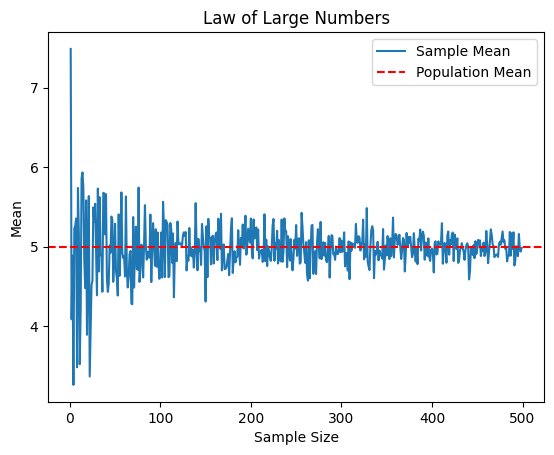

In [30]:
sample_sizes = np.arange(1, 500)
means = []

for n in sample_sizes:
    sample = np.random.choice(population, size=n)
    means.append(sample.mean())

plt.plot(sample_sizes, means, label="Sample Mean")
plt.axhline(population.mean(), color='red', linestyle='--', label="Population Mean")
plt.legend()
plt.title("Law of Large Numbers")
plt.xlabel("Sample Size")
plt.ylabel("Mean")
plt.show()

**Insights**

* Alta variância em amostras pequenas
* Estabilidade conforme n cresce

Usando a seguinte distribuição normal:
```python
rng = np.random.default_rng(seed=42)
population = rng.normal()
```
onde:
loc é a média($\mu$), scale($\sigma$) é o desvio padrão e size(N) é quantos valores gerar.

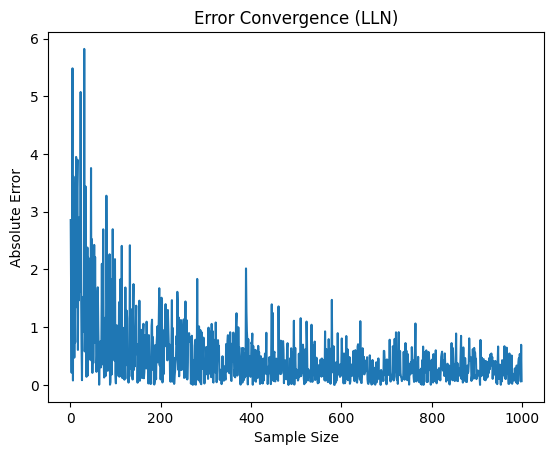

In [31]:
population = rng.normal(loc=50, scale=10, size=100000)
# mu = 50, sigma = 10
# N = 100_000
sample_sizes = np.arange(1, 1000)
errors = []

for n in sample_sizes:
    sample = np.random.choice(population, size=n)
    error = abs(sample.mean() - population.mean())
    errors.append(error)

plt.plot(sample_sizes, errors)
plt.title("Error Convergence (LLN)")
plt.xlabel("Sample Size")
plt.ylabel("Absolute Error")
plt.show()

# Central Limit Theorem (CLT)

**Conceito**

A média amostral segue uma distribuição normal para n suficientemente grande,
independente da distribuição original.

Formalmente:

$$\bar{X} \sim N\left(\mu, \frac{\sigma}{\sqrt{n}}\right)$$

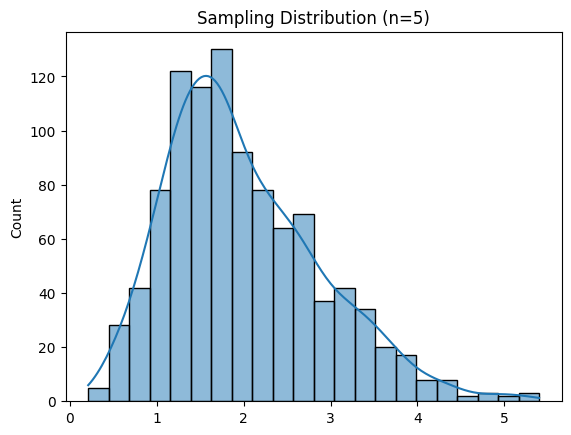

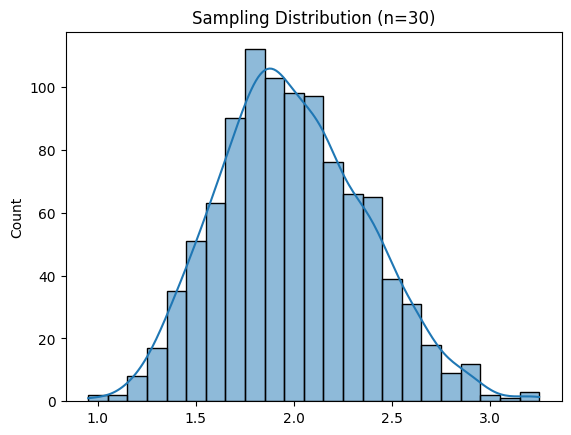

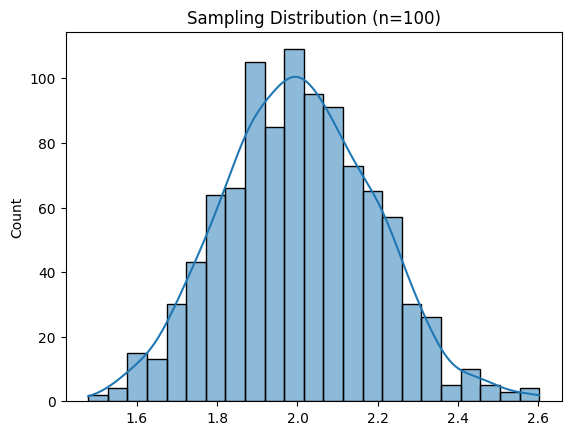

In [32]:
# population = rng.exponential(scale=2, size=100000)
rng = np.random.default_rng(seed=42)
population = rng.exponential(scale=2, size=100_000)


def sampling_distribution(n: int, B: int = 1000) -> list[float]:
    """Gera a distribuição amostral da média via simulação.

    Retira B amostras de tamanho n da população global e calcula
    a média de cada uma, produzindo a distribuição amostral de x̄.

    Args:
        n: Tamanho de cada amostra.
        B: Número de amostras geradas. Default 1000.

    Returns:
        Lista com B médias amostrais.

    Example:
        >>> means = sampling_distribution(n=50)
        >>> len(means)
        1000
    """
    return [
        rng.choice(population, size=n).mean()
        for _ in range(B)
    ]

for n in [5, 30, 100]:
    means = sampling_distribution(n)
    sns.histplot(means, kde=True)
    plt.title(f"Sampling Distribution (n={n})")
    plt.show()

Dos gráficos acima vemos que a medida que n cresce o histograma vai se aproximando da normal

Usando uma distribuição binomial

1. Gere sampling distributions para n = 10, 50, 200
2. Compare visualmente

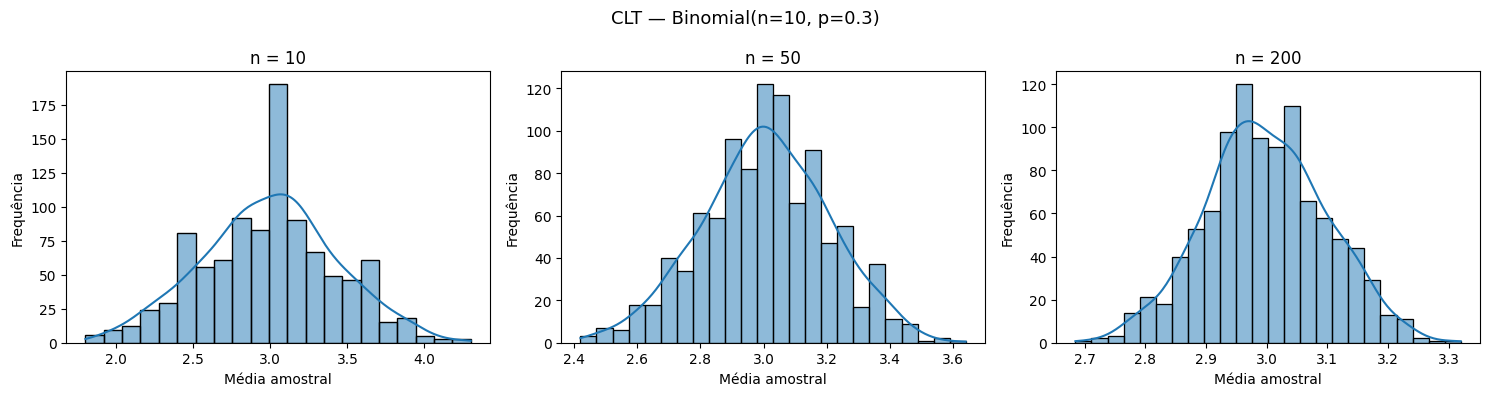

In [33]:
population = rng.binomial(n=10, p=0.3, size=100_000)

sample_sizes = [10, 50, 200]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle("CLT — Binomial(n=10, p=0.3)", fontsize=13)

for ax, n in zip(axes, sample_sizes):
    means = [
        rng.choice(population, size=n).mean() # sorteia o tamanho da amostra e calcula a média
        for _ in range(1000)
    ]
    sns.histplot(means, kde=True, ax=ax)
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Média amostral")
    ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

## Bootstrapping

**Conceito**

Reamostragem com reposição para estimar a distribuição de uma estatística.

**Formalmente:**

Dado um dataset $D$:

1. Criamos múltiplas amostras com reposição
2. Calculamos estatísticas em cada amostra

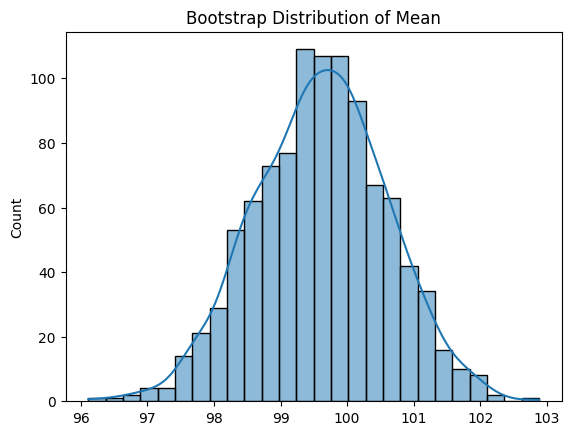

In [34]:
data = rng.normal(loc=100, scale=15, size=200)
# mu = 100, sigma = 15
# N = 200

bootstrap_means = []

for _ in range(1000):
    sample = rng.choice(data, size = len(data), replace=True)
    bootstrap_means.append(sample.mean())

sns.histplot(bootstrap_means, kde=True)
plt.title("Bootstrap Distribution of Mean")
plt.show()

Amostra original:  n=50
x̄ = 68.28  |  s = 9.61
μ real (teórico) = 70  |  σ real (teórico) = 10

Distribuição bootstrap:  B=2000 amostras
Média das médias boot:   68.29  (deve ≈ x̄)
SE empírico (bootstrap): 1.37  (deve ≈ σ/√n = 1.41)

IC 95% Bootstrap:  [65.62,  70.97]
Amplitude do IC:   5.35


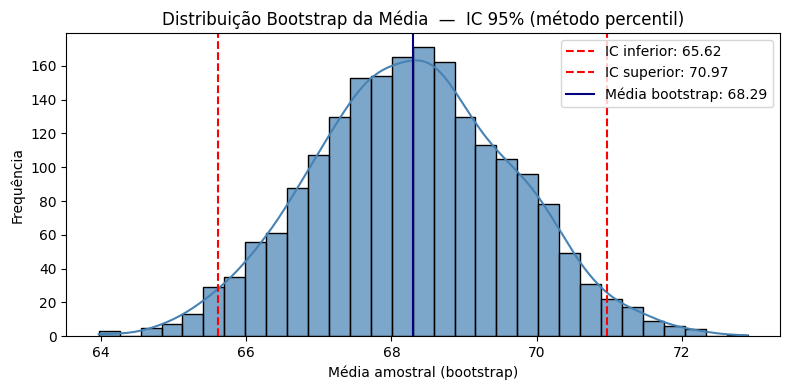

In [35]:
# ── Dados originais ──────────────────────────────────────────────
# Simulamos uma amostra de n=50 de uma população Normal(μ=70, σ=10)
# Na prática: seria seu dataset real (ex: notas, salários, churn score)
data = rng.normal(loc=70, scale=10, size=50)

print(f"Amostra original:  n={len(data)}")
print(f"x̄ = {data.mean():.2f}  |  s = {data.std(ddof=1):.2f}")
print("μ real (teórico) = 70  |  σ real (teórico) = 10")

# ── Bootstrap ────────────────────────────────────────────────────
# A cada iteração: retiramos n valores COM reposição da própria amostra
# e calculamos a média — isso gera a distribuição amostral de x̄
# sem precisar de novos dados nem assumir normalidade
B = 2000
bootstrap_means = [
    rng.choice(data, size=len(data), replace=True).mean()
    for _ in range(B)
]

print(f"\nDistribuição bootstrap:  B={B} amostras")
print(f"Média das médias boot:   {np.mean(bootstrap_means):.2f}  (deve ≈ x̄)")
print(f"SE empírico (bootstrap): {np.std(bootstrap_means):.2f}  (deve ≈ σ/√n = {10/50**0.5:.2f})")

# ── Intervalo de Confiança 95% — método percentil ────────────────
# Pegamos os percentis 2.5% e 97.5% da distribuição bootstrap
# Interpretação: em 95% das amostras possíveis, x̄ cairia nesse intervalo
lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print(f"\nIC 95% Bootstrap:  [{lower:.2f},  {upper:.2f}]")
print(f"Amplitude do IC:   {upper - lower:.2f}")

# ── Visualização ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(bootstrap_means, kde=True, ax=ax, color="steelblue", alpha=0.7)

ax.axvline(lower, color="red", linestyle="--", linewidth=1.5,
           label=f"IC inferior: {lower:.2f}")
ax.axvline(upper, color="red", linestyle="--", linewidth=1.5,
           label=f"IC superior: {upper:.2f}")
ax.axvline(np.mean(bootstrap_means), color="navy", linestyle="-", linewidth=1.5,
           label=f"Média bootstrap: {np.mean(bootstrap_means):.2f}")

ax.set_title("Distribuição Bootstrap da Média  —  IC 95% (método percentil)")
ax.set_xlabel("Média amostral (bootstrap)")
ax.set_ylabel("Frequência")
ax.legend()

plt.tight_layout()
plt.show()

| Conceito              | Papel                     |
| --------------------- | ------------------------- |
| Sampling Distribution | Base de inferência        |
| LLN                   | Consistência do estimador |
| CLT                   | Normalidade assintótica   |
| Bootstrapping         | Aproximação empírica      |


**"Quando usar boostrapping ao invés de CLT?"**

A pergunta real é: **Você consegue calcular o SE analiticamente ou não?**
```
Você tem uma estatística de interesse
            │
            ├── É uma média (ou proporção)?
            │        │
            │        └── n ≥ 30?
            │                 ├── Sim → CLT, IC analítico: x̄ ± 1.96 × s/√n
            │                 └── Não → Bootstrap
            │
            └── É mediana, correlação, R², AUC, RMSE?
                      │
                      └── Sempre Bootstrap
                          (CLT não tem forma fechada para esses)
```

* Quando n é pequeno
* Quando distribuição é desconhecida
* Quando estatística não tem forma analítica simples
* Quando queremos evitar suposições paramétricas
